# Notebook 5: Activation Patching
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Kausale Intervention — welche Schichten und Positionen tragen zur richtigen Antwort bei?

> **Aufgabe:** Implementiere die Zellen schrittweise. Dies ist das komplexeste Notebook\!
> 
> Hilfreiche Dokumentation:
> - PyTorch Hooks: https://pytorch.org/docs/stable/generated/torch.nn.Module.register_forward_hook.html
> - PyTorch Tensor clone: https://pytorch.org/docs/stable/generated/torch.Tensor.clone.html
> - Matplotlib Imshow: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html

> **Empfehlung:** Lies zuerst den Hintergrund vollständig durch, bevor du beginnst.

## Hintergrund: Activation Patching — der Gold-Standard

### Das Problem mit Attention und Probing
- **Attention-Analyse**: Zeigt Korrelationen, keine Kausalität
- **Probing**: Zeigt, wo Information kodiert ist — nicht ob sie für die Ausgabe genutzt wird

### Die Idee
Activation Patching führt ein **kontrolliertes Experiment** durch:

```
Clean:     "The capital of France is"  →  P(" Paris") = hoch
Corrupted: "The capital of Xyzzy is"   →  P(" Paris") = niedrig
```

Dann: Korrupten Run wiederholen, aber die Aktivierung einer bestimmten **Schicht L** bei **Position P** mit der sauberen Version ersetzen.

**Wenn der Effekt stark ist** (P(" Paris") steigt nach dem Patchen):  
→ Diese Schicht/Position *enthält* die entscheidende Information

### Der Patching-Effekt
```
Effect(L, P) = logit_patched(" Paris") - logit_corrupt(" Paris")
```

Oder normalisiert:
```
Normalized_Effect(L, P) = (logit_patched - logit_corrupt) / (logit_clean - logit_corrupt)
```
Wert nahe 1.0 = vollständige Wiederherstellung der sauberen Vorhersage

## 1. Setup

In [1]:
# TODO: Importiere torch, numpy, matplotlib
# TODO: Lade Tokenizer und Modell (wie in Notebook 1)
#
# MODEL_NAME = "EleutherAI/pythia-410m"
# n_layers = model.config.num_hidden_layers

from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

MODEL_NAME = "EleutherAI/pythia-410m"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tokenizer laden
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Falls kein pad_token vorhanden
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Modell laden
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",   # wichtig für Attention-Ausgabe
    torch_dtype=torch.float32
)

# Auf Gerät verschieben
model = model.to(device)

# Eval-Modus
model.eval()
n_layers = model.config.num_hidden_layers
print("Modell geladen!")
print("Device:", device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Modell geladen!
Device: cuda


## 2. Clean und Corrupted Prompts

In [2]:


# TODO: Bestimme die Token-ID des korrekten Antworttokens:
#   correct_tok_id = tokenizer.encode(correct_answer)[0]
#
# TODO: Tokenisiere BEIDE Prompts und stelle sicher, dass sie GLEICH LANG sind.
#   WICHTIG: Beide Inputs müssen dieselbe Sequenzlänge haben\!
#   Falls sie unterschiedlich lang sind, wähle einen anderen corrupted Prompt.
#
# TODO: Gib beide Token-Listen aus und vergleiche sie visuell.
# TODO: Führe Forward Passes für beide durch und vergleiche P(" Paris").
#
# Frage: Wie groß ist der Unterschied in P(" Paris") zwischen Clean und Corrupted?

clean_prompt     = "The movie was good. The sentiment is"
corrupted_prompt = "The movie was terrible. The sentiment is"
correct_answer   = " positive"

correct_tok_id = tokenizer.encode(correct_answer)[0]

print("Correct token ID:", correct_tok_id)
print("Decoded token:", tokenizer.decode([correct_tok_id]))

# Beide Prompts tokenisieren
inputs_clean = tokenizer(clean_prompt, return_tensors="pt").to(device)
inputs_corr  = tokenizer(corrupted_prompt, return_tensors="pt").to(device)

# Token-Listen
tokens_clean = [tokenizer.decode([t]) for t in inputs_clean["input_ids"][0]]
tokens_corr  = [tokenizer.decode([t]) for t in inputs_corr["input_ids"][0]]

print("Clean tokens:    ", tokens_clean)
print("Corrupted tokens:", tokens_corr)

# Prüfen: gleiche Sequenzlänge?
print("Clean length:    ", len(tokens_clean))
print("Corrupted length:", len(tokens_corr))

assert len(tokens_clean) == len(tokens_corr), "Token-Längen müssen gleich sein!"

# Forward Passes
with torch.no_grad():
    outputs_clean = model(**inputs_clean)
    outputs_corr  = model(**inputs_corr)

# Logits der letzten Position
logits_clean = outputs_clean.logits[0, -1, :]
logits_corr  = outputs_corr.logits[0, -1, :]

clean_logit = logits_clean[correct_tok_id].item()
corr_base_logit = logits_corr[correct_tok_id].item()
# Wahrscheinlichkeiten
probs_clean = torch.softmax(logits_clean, dim=-1)
probs_corr  = torch.softmax(logits_corr, dim=-1)


p_clean = probs_clean[correct_tok_id].item()
p_corr  = probs_corr[correct_tok_id].item()

diff = p_clean - p_corr

print("Clean logit:", clean_logit)
print("Corrupted baseline logit:", corr_base_logit)
print(f'P(" positive") clean:     {p_clean:.6f}')
print(f'P(" positive") corrupted: {p_corr:.6f}')
print(f'Difference:            {diff:.6f}')

Correct token ID: 2762
Decoded token:  positive
Clean tokens:     ['The', ' movie', ' was', ' good', '.', ' The', ' sentiment', ' is']
Corrupted tokens: ['The', ' movie', ' was', ' terrible', '.', ' The', ' sentiment', ' is']
Clean length:     8
Corrupted length: 8
Clean logit: 12.740194320678711
Corrupted baseline logit: 10.573139190673828
P(" positive") clean:     0.003394
P(" positive") corrupted: 0.000464
Difference:            0.002931


## 3. Schritt 1: Clean-Aktivierungen cachen

In [11]:
# TODO: Registriere Forward Hooks auf ALLEN Schichten des clean-Modells.
#   Ziel: Die Hidden States aller Schichten für den clean-Prompt speichern.
#
# Muster:
#   clean_cache = {}
#   for i, layer in enumerate(model.gpt_neox.layers):
#       def make_hook(layer_idx):
#           def hook_fn(module, input, output):
#               clean_cache[layer_idx] = output[0].detach().clone()
#               return output  # Wichtig: output unverändert zurückgeben\!
#           return hook_fn
#       layer.register_forward_hook(make_hook(i))
#
# TODO: Führe den Forward Pass durch.
# TODO: Entferne alle Hooks danach\!
#
# WICHTIG: .detach().clone() — warum beide?
#   .detach(): Löst vom Berechnungsgraphen (kein Gradient-Tracking)
#   .clone():  Erstellt eine echte Kopie (nicht nur eine Referenz)
#
# Dokumentation: https://pytorch.org/docs/stable/generated/torch.Tensor.clone.html
clean_cache = {}
handles = []

for i, layer in enumerate(model.gpt_neox.layers):
    def make_hook(layer_idx):
        def hook_fn(module, input, output):
            # output[0] = hidden states: shape [batch, seq_len, hidden_size]
            clean_cache[layer_idx] = output[0].detach().clone()
            return output
        return hook_fn

    handle = layer.register_forward_hook(make_hook(i))
    handles.append(handle)

# Forward Pass clean
with torch.no_grad():
    outputs_clean = model(**inputs_clean)

# Hooks entfernen
for handle in handles:
    handle.remove()

print("Gespeicherte Layer:", clean_cache.keys())
print("Anzahl Layer:", len(clean_cache))
print("Shape Layer 0:", clean_cache[0].shape)

Gespeicherte Layer: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])
Anzahl Layer: 24
Shape Layer 0: torch.Size([8, 1024])


## 4. Schritt 2: Patching-Funktion implementieren

In [ ]:
# TODO: Implementiere patch_and_measure(patch_layer, patch_pos):
#
# Diese Funktion:
#   1. Registriert einen Hook auf model.gpt_neox.layers[patch_layer]
#   2. Der Hook ERSETZT die Aktivierung bei patch_pos mit clean_cache[patch_layer][0, patch_pos, :]
#   3. Führt den KORRUPTEN Forward Pass durch (corrupted_inputs\!)
#   4. Entfernt den Hook (try/finally für Sicherheit\!)
#   5. Gibt den Logit-Wert des correct_tok_id zurück
#
# Kritischer Code im Hook:
#   modified = output[0].clone()
#   modified[0, patch_pos, :] = clean_cache[target_layer][0, patch_pos, :]
#   return (modified,) + output[1:]   # Tuple-Struktur beibehalten\!
#
# WICHTIG: Pythia gibt (hidden_state, attention_probs, ...) als Tuple zurück.
#   Du MUSST das Tuple korrekt zurückgeben, sonst crasht das Modell.
#
# Tipp: Teste die Funktion erst mit einem einzelnen Wert, z.B.:
#   test_logit = patch_and_measure(patch_layer=10, patch_pos=-1)
#   print(f"Test Logit: {test_logit}")

def patch_and_measure(patch_layer, patch_pos):
    target_layer = patch_layer
    handle = None

    def hook_fn(module, input, output):
        #print(output.shape)
        modified =  output.clone()

        clean_hidden = clean_cache[target_layer]
        
        #print(clean_hidden.dim())
        clean_vec = clean_hidden[patch_pos, :]

        #print(modified.dim())
        modified[0, patch_pos, :] = clean_vec

        if isinstance(output, tuple):
            return (modified,) + output[1:]
        return modified

    try:
        handle = model.gpt_neox.layers[target_layer].register_forward_hook(hook_fn)

        with torch.no_grad():
            outputs = model(**inputs_corr)

        logit = outputs.logits[0, -1, correct_tok_id].item()

    finally:
        if handle is not None:
            handle.remove()

    return logit
    
test_logit = patch_and_measure(patch_layer=23, patch_pos=-1)
print(f"Test Logit: {test_logit}")





Test Logit: 12.740194320678711


## 5. Schritt 3: Alle Layer × Positionen patchen

In [19]:
# TODO: Berechne den Patching-Effekt für ALLE Kombinationen:
#   results = np.zeros((n_layers, seq_len))
#   for layer in range(n_layers):
#       for pos in range(seq_len):
#           results[layer, pos] = patch_and_measure(layer, pos)
#
# WARNUNG: Dies dauert einige Minuten (24 Schichten × Sequenzlänge Forward Passes).
# Tipp: Gib alle 4 Schichten eine Fortschrittsmeldung aus.
#
# Nach der Schleife: Berechne den normalisierten Patching-Effekt:
#   normalized = (results - corr_base_logit) / (clean_logit - corr_base_logit)
#   0 = kein Effekt, 1 = vollständige Wiederherstellung


n_layers = len(model.gpt_neox.layers)
seq_len = inputs_corr["input_ids"].shape[1]

results = np.zeros((n_layers, seq_len))

for layer in range(n_layers):
    if layer % 4 == 0:
        print(f"Processing layer {layer}/{n_layers}")

    for pos in range(seq_len):
        results[layer, pos] = patch_and_measure(layer, pos)

print("Done.")



Processing layer 0/24
Processing layer 4/24
Processing layer 8/24
Processing layer 12/24
Processing layer 16/24
Processing layer 20/24
Done.


In [20]:
print(results)

[[10.57313919 10.57313919 10.57313919 12.46138    10.60683823 10.59995079
  10.74802494 10.58355904]
 [10.57313919 10.57313919 10.57313919 12.4483757  10.60050488 10.58574867
  10.78551769 10.589468  ]
 [10.57313919 10.57313919 10.57313919 12.4185257  10.58146477 10.58616924
  10.78345013 10.58131218]
 [10.57313919 10.57313919 10.57313919 12.27556705 10.55975628 10.52610302
  10.88284588 10.62966919]
 [10.57313919 10.57313919 10.57313919 12.30130386 10.61431694 10.54466629
  10.86654282 10.64797592]
 [10.57313919 10.57313919 10.57313919 11.84929657 10.42574692 10.51624107
  10.89557266 10.69895554]
 [10.57313919 10.57313919 10.57313919 11.88403702 10.41736984 10.52141476
  10.84418011 10.76599693]
 [10.57313919 10.57313919 10.57313919 11.85483742 10.50633812 10.56342506
  10.7123394  10.7657547 ]
 [10.57313919 10.57313919 10.57313919 11.87138844 10.60916138 10.56656265
  10.6724205  10.72276306]
 [10.57313919 10.57313919 10.57313919 12.07107639 10.56146526 10.53285313
  10.62570572 10.

In [21]:
print("clean_logit:", clean_logit)
print("corr_base_logit:", corr_base_logit)
print("denom:", clean_logit - corr_base_logit)

print("P clean:", p_clean)
print("P corrupted:", p_corr)

clean_logit: 12.740194320678711
corr_base_logit: 10.573139190673828
denom: 2.167055130004883
P clean: 0.003394488478079438
P corrupted: 0.0004635428194887936


In [22]:
denom = clean_logit - corr_base_logit

if abs(denom) < 1e-8:
    raise ValueError("clean_logit and corr_base_logit are too close.")

normalized = (results - corr_base_logit) / denom

best_layer, best_pos = np.unravel_index(np.argmax(normalized), normalized.shape)

print("Best layer:", best_layer)
print("Best position:", best_pos)
print("Best normalized effect:", normalized[best_layer, best_pos])

flat_indices = np.argsort(normalized.ravel())[::-1]

for idx in flat_indices[:10]:
    layer, pos = np.unravel_index(idx, normalized.shape)
    print(f"Layer {layer:02d}, Pos {pos:02d}, Effect {normalized[layer, pos]:.3f}")

Best layer: 23
Best position: 7
Best normalized effect: 1.0
Layer 23, Pos 07, Effect 1.000
Layer 21, Pos 07, Effect 0.971
Layer 22, Pos 07, Effect 0.965
Layer 19, Pos 07, Effect 0.950
Layer 17, Pos 07, Effect 0.947
Layer 18, Pos 07, Effect 0.946
Layer 20, Pos 07, Effect 0.942
Layer 00, Pos 03, Effect 0.871
Layer 01, Pos 03, Effect 0.865
Layer 02, Pos 03, Effect 0.852


## 6. Heatmap visualisieren

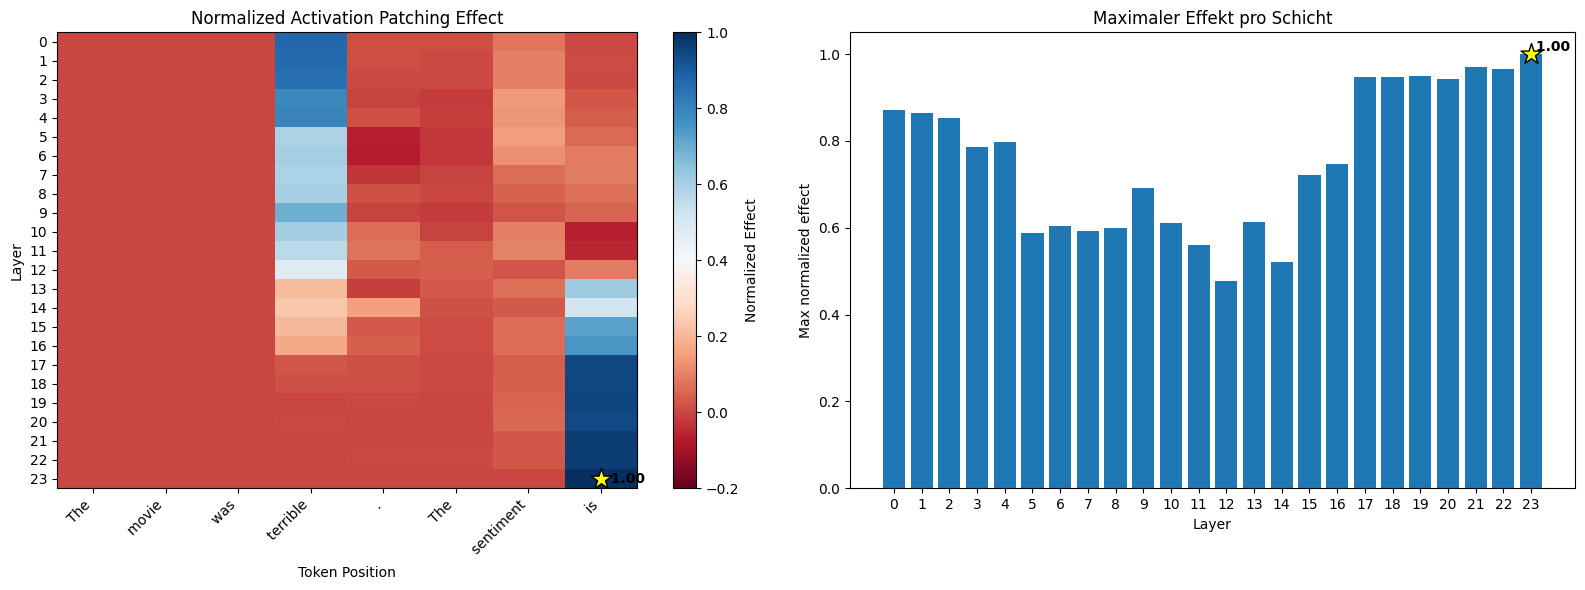

Schicht mit größtem Einfluss: 23
Wichtigste Token-Position: 7
Token clean:  is
Token corrupted:  is
Effekt: 1.0


In [25]:
# TODO: Erstelle eine Heatmap der normalisierten Patching-Effekte:
#   - Y-Achse: Schichten (0 bis n_layers-1)
#   - X-Achse: Token-Positionen
#   - Farbe: normalisierter Effekt (cmap="RdBu", vmin=-0.2, vmax=1.0)
#   - X-Achsen-Labels: Token-Strings (clean_tokens)
#
# TODO: Markiere den stärksten Punkt (höchster normalisierter Effekt)
#   Tipp: np.unravel_index(np.argmax(normalized), normalized.shape)
#
# TODO: Erstelle daneben ein Balkendiagramm: maximaler Effekt pro Schicht
#   (max über alle Positionen für jede Schicht)
#
# Frage: Welche Schicht hat den größten Einfluss auf die Vorhersage?
# Frage: Welche Token-Position ist am wichtigsten?
best_layer, best_pos = np.unravel_index(np.argmax(normalized), normalized.shape)
best_effect = normalized[best_layer, best_pos]

# maximaler Effekt pro Schicht
max_per_layer = normalized.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Heatmap
im = axes[0].imshow(
    normalized,
    aspect="auto",
    cmap="RdBu",
    vmin=-0.2,
    vmax=1.0
)

axes[0].set_title("Normalized Activation Patching Effect")
axes[0].set_xlabel("Token Position")
axes[0].set_ylabel("Layer")

axes[0].set_xticks(np.arange(len(tokens_corr)))
axes[0].set_xticklabels(tokens_corr, rotation=45, ha="right")

axes[0].set_yticks(np.arange(n_layers))

# stärksten Punkt markieren
axes[0].scatter(best_pos, best_layer, marker="*", s=250, color="yellow", edgecolor="black")
axes[0].text(
    best_pos,
    best_layer,
    f"  {best_effect:.2f}",
    color="black",
    va="center",
    fontweight="bold"
)

fig.colorbar(im, ax=axes[0], label="Normalized Effect")

# 2) Balkendiagramm
axes[1].bar(np.arange(n_layers), max_per_layer)
axes[1].set_title("Maximaler Effekt pro Schicht")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Max normalized effect")
axes[1].set_xticks(np.arange(n_layers))

# beste Schicht markieren
axes[1].scatter(best_layer, max_per_layer[best_layer], marker="*", s=250, color="yellow", edgecolor="black")
axes[1].text(
    best_layer,
    max_per_layer[best_layer],
    f" {max_per_layer[best_layer]:.2f}",
    va="bottom",
    fontweight="bold"
)

plt.tight_layout()
plt.show()
print("Schicht mit größtem Einfluss:", best_layer)
print("Wichtigste Token-Position:", best_pos)
print("Token clean:", tokens_clean[best_pos])
print("Token corrupted:", tokens_corr[best_pos])
print("Effekt:", best_effect)

In [26]:
np.savez("patching_results.npz",
         recovery=normalized,
         tokens=np.array(tokens_corr),
         p_clean=p_clean,
         p_corrupted=p_corr)
print("Gespeichert: patching_results.npz")

Gespeichert: patching_results.npz


## 7. Top-Patching-Punkte analysieren

In [ ]:
# TODO: Erstelle eine Rangliste der Top-10 (Layer, Position)-Kombinationen
#   nach normalisiertem Patching-Effekt.
#
# TODO: Beantworte: Befindet sich der wichtigste Patch-Punkt beim
#   Token "France"? Bei welcher Schicht? Was bedeutet das?
#
# Tipp: np.argsort(normalized.ravel())[::-1] sortiert absteigend
# Tipp: divmod(flat_idx, seq_len) gibt (layer, pos) zurück
flat_indices = np.argsort(normalized.ravel())[::-1]

print("Top-10 Patching Effects:")
print("-" * 70)

for rank, flat_idx in enumerate(flat_indices[:10], start=1):
    layer, pos = divmod(flat_idx, seq_len)
    effect = normalized[layer, pos]

    print(
        f"{rank:02d}. "
        f"Layer {layer:02d}, "
        f"Pos {pos:02d}, "
        f"Token clean={tokens_clean[pos]!r}, "
        f"Token corr={tokens_corr[pos]!r}, "
        f"Effect={effect:.3f}"
    )



best_layer, best_pos = np.unravel_index(np.argmax(normalized), normalized.shape)

print("Best layer:", best_layer)
print("Best pos:", best_pos)
print("Clean token:", tokens_clean[best_pos])
print("Corrupted token:", tokens_corr[best_pos])

Top-10 Patching Effects:
----------------------------------------------------------------------
01. Layer 23, Pos 07, Token clean=' is', Token corr=' is', Effect=1.000
02. Layer 21, Pos 07, Token clean=' is', Token corr=' is', Effect=0.971
03. Layer 22, Pos 07, Token clean=' is', Token corr=' is', Effect=0.965
04. Layer 19, Pos 07, Token clean=' is', Token corr=' is', Effect=0.950
05. Layer 17, Pos 07, Token clean=' is', Token corr=' is', Effect=0.947
06. Layer 18, Pos 07, Token clean=' is', Token corr=' is', Effect=0.946
07. Layer 20, Pos 07, Token clean=' is', Token corr=' is', Effect=0.942
08. Layer 00, Pos 03, Token clean=' good', Token corr=' terrible', Effect=0.871
09. Layer 01, Pos 03, Token clean=' good', Token corr=' terrible', Effect=0.865
10. Layer 02, Pos 03, Token clean=' good', Token corr=' terrible', Effect=0.852
Best layer: 23
Best pos: 7
Clean token:  is
Corrupted token:  is


## 8. BONUS: Head-Level Patching

In [ ]:
# BONUS-AUFGABE: Statt ganzer Schichten, patche einzelne Attention Heads.
#
# Für Head-Level Patching musst du in den Attention-Output eingreifen.
# In Pythia: model.gpt_neox.layers[i].attention
#
# Der Attention-Output hat die Form: (batch, seq, n_heads, head_dim)
# oder nach Reshape: (batch, seq, hidden_size)
#
# Herausforderung: Den Output eines einzelnen Heads zu isolieren und zu ersetzen.
#   head_dim = hidden_size // n_heads
#   start_idx = head * head_dim
#   end_idx   = (head + 1) * head_dim
#
# Welcher Attention Head ist am wichtigsten für die Vorhersage von " Paris"?
# Vergleiche dein Ergebnis mit der Attention-Analyse aus Notebook 3\!

attn_clean_cache = {}
handles = []

for layer_idx, layer in enumerate(model.gpt_neox.layers):

    def make_hook(layer_idx):
        def hook_fn(module, input, output):
            hidden = output[0] if isinstance(output, tuple) else output
            attn_clean_cache[layer_idx] = hidden.detach().clone()
            return output
        return hook_fn

    h = layer.attention.register_forward_hook(make_hook(layer_idx))
    handles.append(h)

with torch.no_grad():
    _ = model(**inputs_clean)

for h in handles:
    h.remove()


In [ ]:
def patch_head_and_measure(patch_layer, patch_pos, patch_head):
    n_heads = model.config.num_attention_heads
    hidden_size = model.config.hidden_size
    head_dim = hidden_size // n_heads

    start_idx = patch_head * head_dim
    end_idx = (patch_head + 1) * head_dim

    def hook_fn(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        modified = hidden.clone()

        clean_hidden = attn_clean_cache[patch_layer]

        if modified.dim() == 3:
            modified[0, patch_pos, start_idx:end_idx] = clean_hidden[0, patch_pos, start_idx:end_idx]
        elif modified.dim() == 2:
            modified[patch_pos, start_idx:end_idx] = clean_hidden[patch_pos, start_idx:end_idx]
        else:
            raise ValueError(f"Unexpected modified shape: {modified.shape}")

        if isinstance(output, tuple):
            return (modified,) + output[1:]
        return modified

    handle = model.gpt_neox.layers[patch_layer].attention.register_forward_hook(hook_fn)

    try:
        with torch.no_grad():
            outputs = model(**inputs_corr)

        return outputs.logits[0, -1, correct_tok_id].item()

    finally:
        handle.remove()


# Test
test_logit = patch_head_and_measure(patch_layer=10, patch_pos=-1, patch_head=0)
print("Test head patch logit:", test_logit)


Test head patch logit: 10.543619155883789


In [ ]:
n_layers = len(model.gpt_neox.layers)
n_heads = model.config.num_attention_heads
seq_len = inputs_corr["input_ids"].shape[1]

head_results = np.zeros((n_layers, n_heads, seq_len))

for layer in range(n_layers):
    print(f"Processing layer {layer}/{n_layers}")

    for head in range(n_heads):
        for pos in range(seq_len):
            head_results[layer, head, pos] = patch_head_and_measure(
                patch_layer=layer,
                patch_pos=pos,
                patch_head=head
            )



Processing layer 0/24
Processing layer 1/24
Processing layer 2/24
Processing layer 3/24
Processing layer 4/24
Processing layer 5/24
Processing layer 6/24
Processing layer 7/24
Processing layer 8/24
Processing layer 9/24
Processing layer 10/24
Processing layer 11/24
Processing layer 12/24
Processing layer 13/24
Processing layer 14/24
Processing layer 15/24
Processing layer 16/24
Processing layer 17/24
Processing layer 18/24
Processing layer 19/24
Processing layer 20/24
Processing layer 21/24
Processing layer 22/24
Processing layer 23/24


In [ ]:
denom = clean_logit - corr_base_logit

if abs(denom) < 1e-8:
    raise ValueError("clean_logit and corr_base_logit are too close.")

head_normalized = (head_results - corr_base_logit) / denom


In [ ]:
best_flat = np.argmax(head_normalized)
best_layer, best_head, best_pos = np.unravel_index(best_flat, head_normalized.shape)

print("\nBest Attention Head Patch:")
print("Best layer:", best_layer)
print("Best head:", best_head)
print("Best position:", best_pos)
print("Clean token:", tokens_clean[best_pos])
print("Corrupted token:", tokens_corr[best_pos])
print("Effect:", head_normalized[best_layer, best_head, best_pos])



flat_indices = np.argsort(head_normalized.ravel())[::-1]

print("\nTop-10 Attention Head Patches:")
for rank, idx in enumerate(flat_indices[:10], start=1):
    layer, head, pos = np.unravel_index(idx, head_normalized.shape)
    effect = head_normalized[layer, head, pos]

    print(
        f"{rank:02d}. "
        f"Layer {layer:02d}, Head {head:02d}, Pos {pos:02d}, "
        f"Token clean={tokens_clean[pos]!r}, "
        f"Token corr={tokens_corr[pos]!r}, "
        f"Effect={effect:.3f}"
    )


Best Attention Head Patch:
Best layer: 13
Best head: 0
Best position: 7
Clean token:  is
Corrupted token:  is
Effect: 0.048686122102820785

Top-10 Attention Head Patches:
01. Layer 13, Head 00, Pos 07, Token clean=' is', Token corr=' is', Effect=0.049
02. Layer 13, Head 06, Pos 07, Token clean=' is', Token corr=' is', Effect=0.047
03. Layer 17, Head 00, Pos 07, Token clean=' is', Token corr=' is', Effect=0.047
04. Layer 13, Head 03, Pos 07, Token clean=' is', Token corr=' is', Effect=0.046
05. Layer 13, Head 08, Pos 07, Token clean=' is', Token corr=' is', Effect=0.044
06. Layer 13, Head 02, Pos 07, Token clean=' is', Token corr=' is', Effect=0.041
07. Layer 16, Head 00, Pos 07, Token clean=' is', Token corr=' is', Effect=0.038
08. Layer 17, Head 14, Pos 07, Token clean=' is', Token corr=' is', Effect=0.034
09. Layer 13, Head 11, Pos 07, Token clean=' is', Token corr=' is', Effect=0.034
10. Layer 00, Head 14, Pos 06, Token clean=' sentiment', Token corr=' sentiment', Effect=0.033


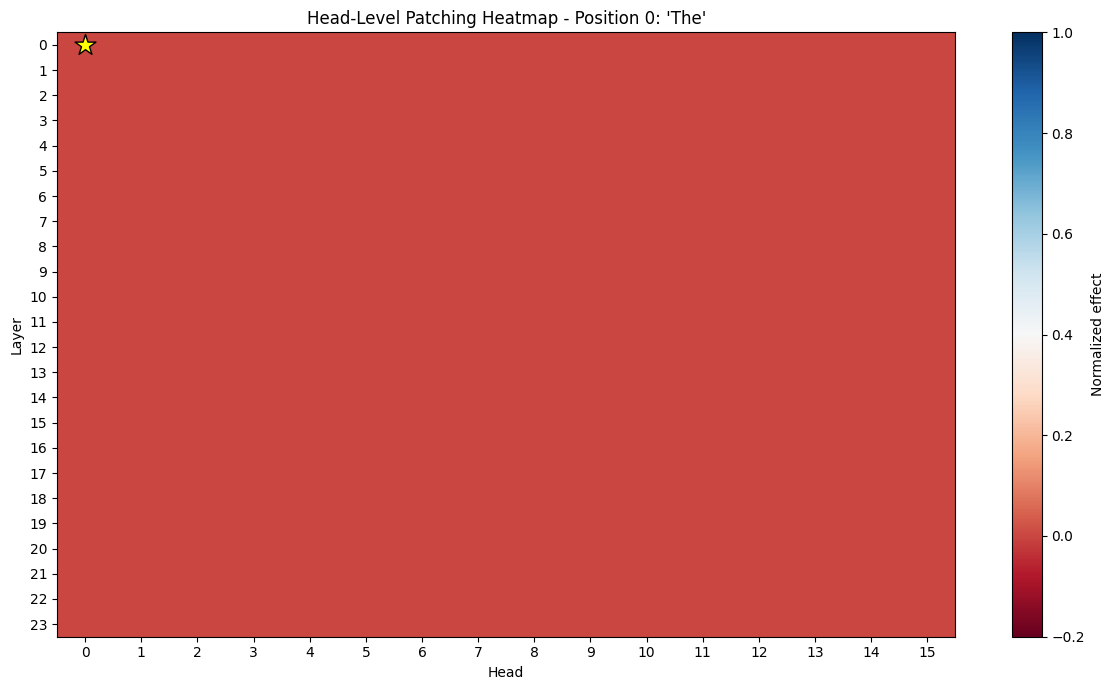

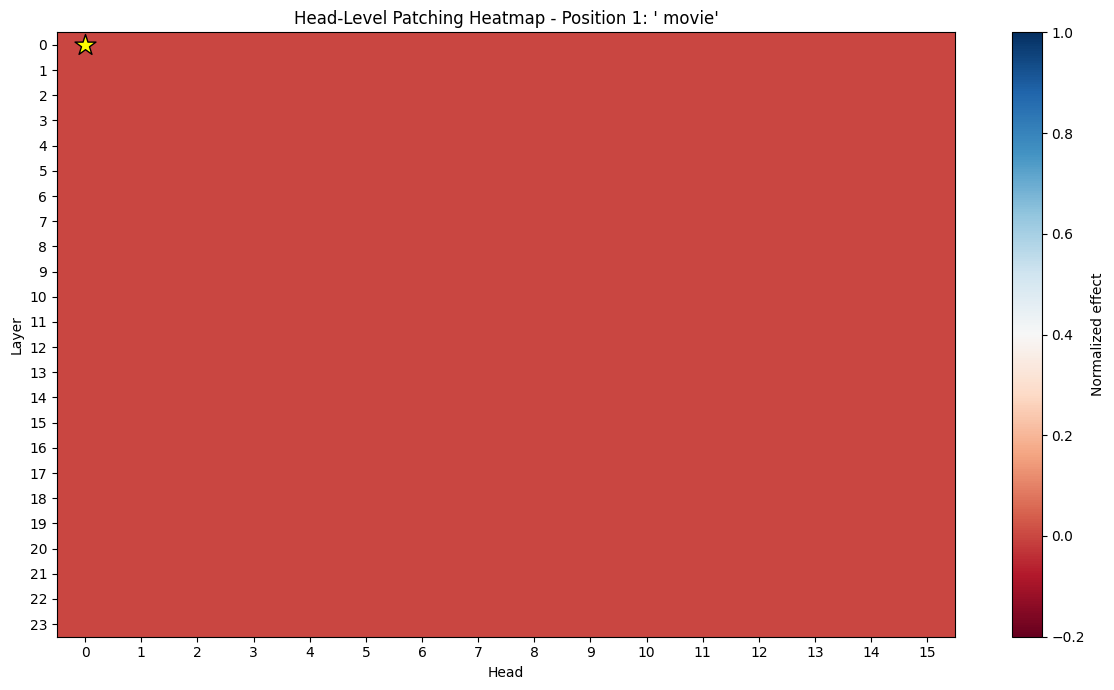

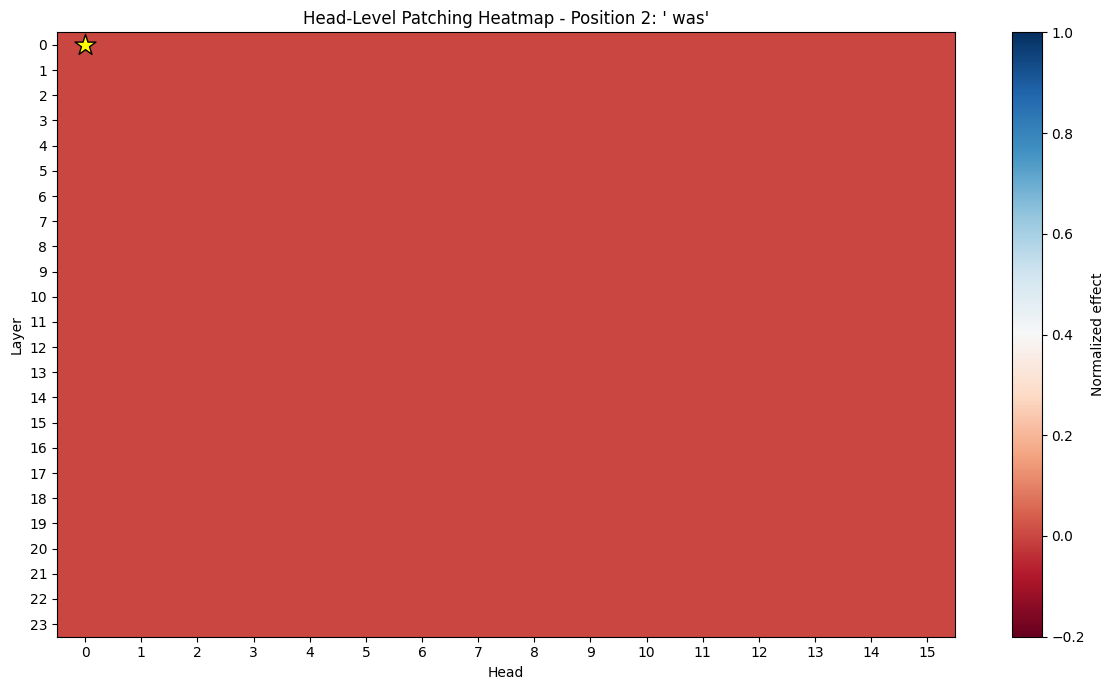

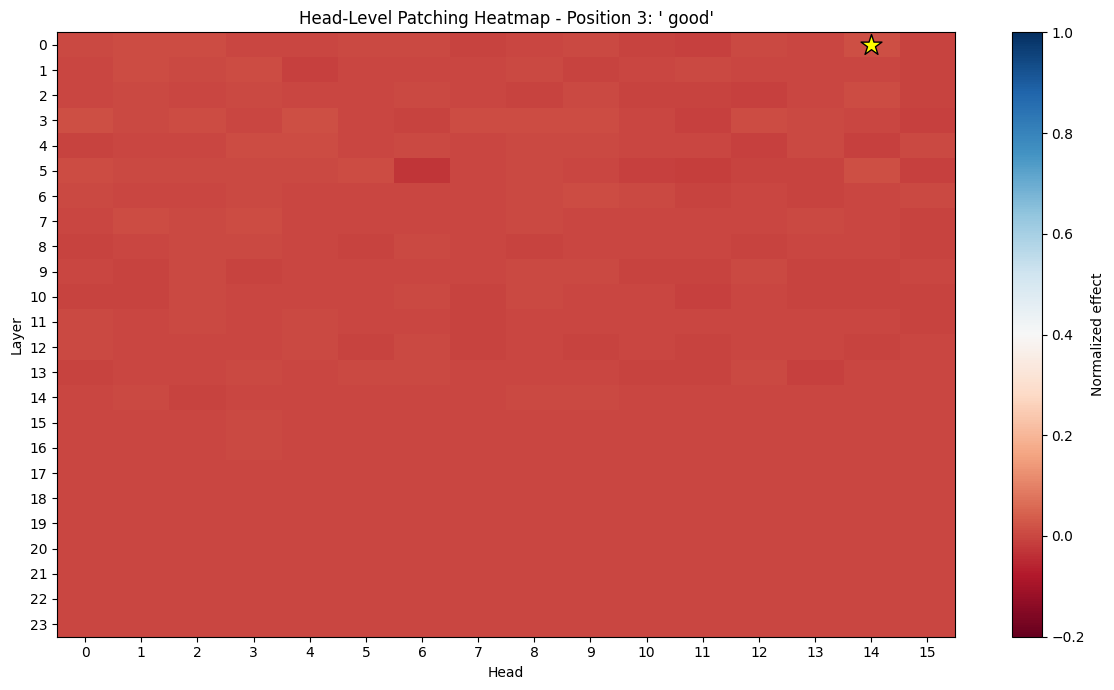

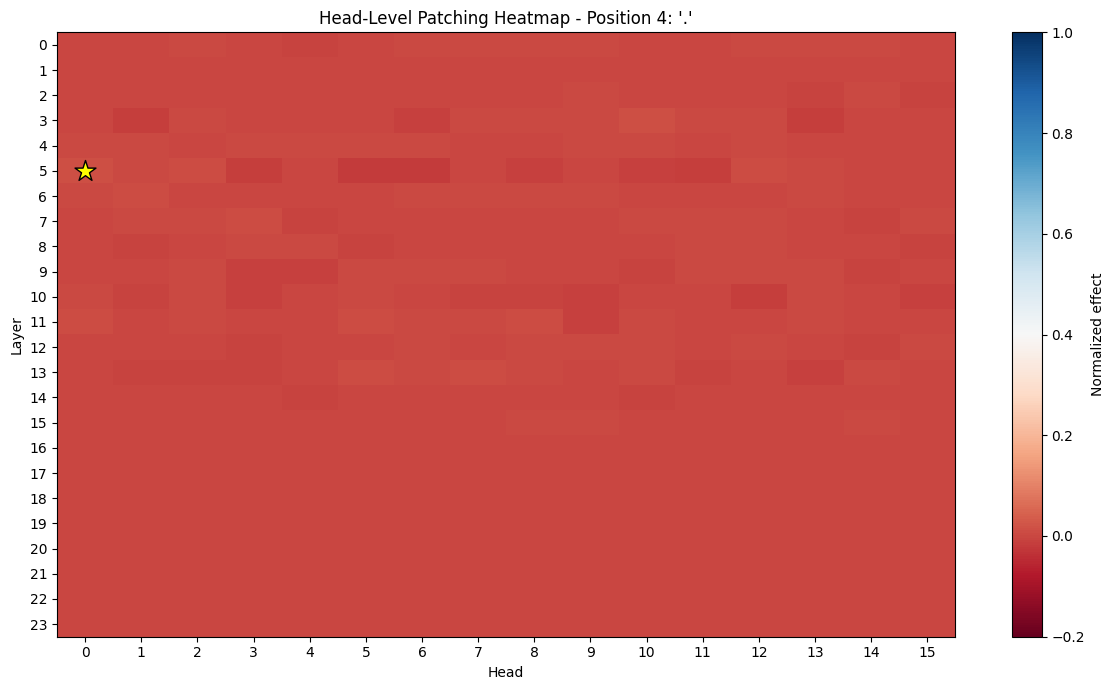

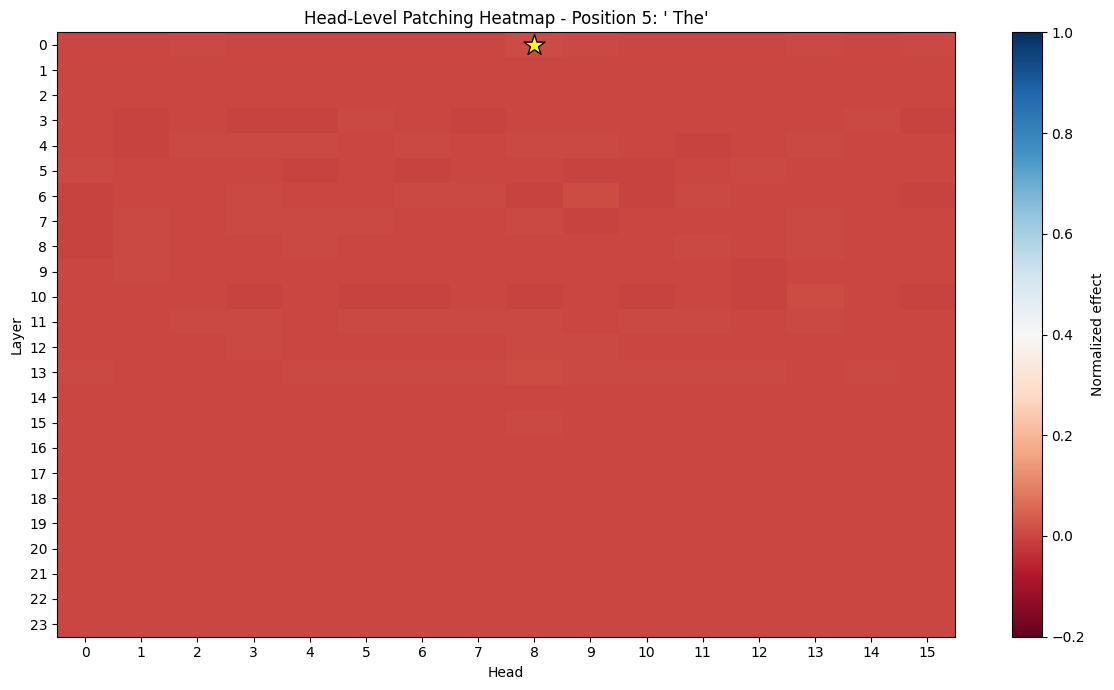

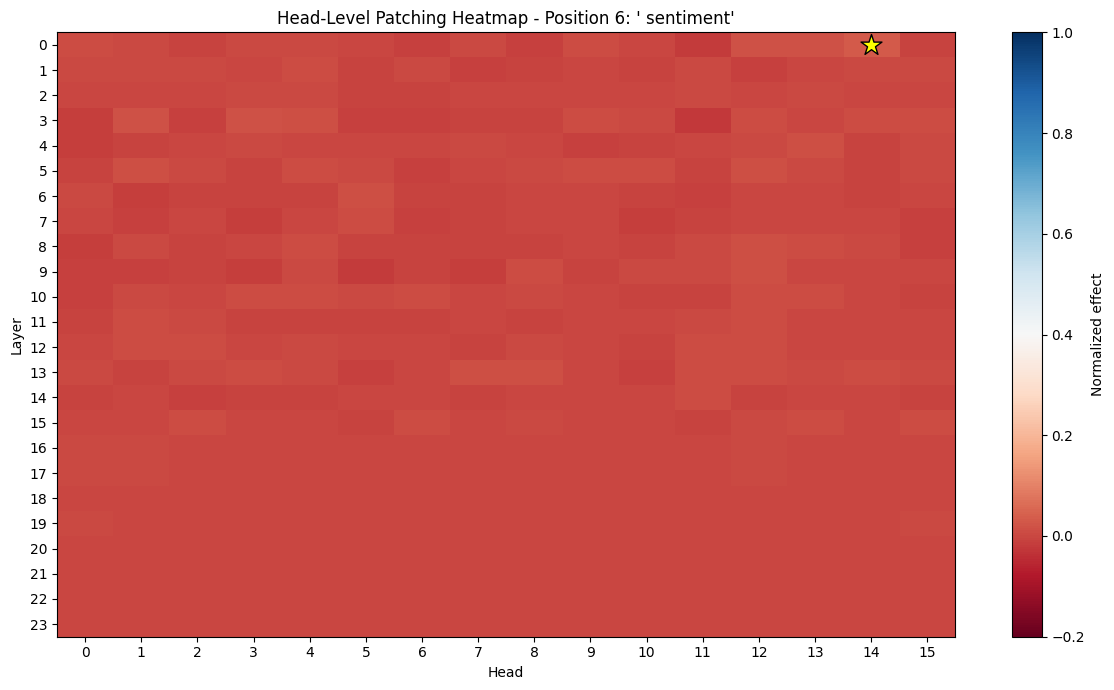

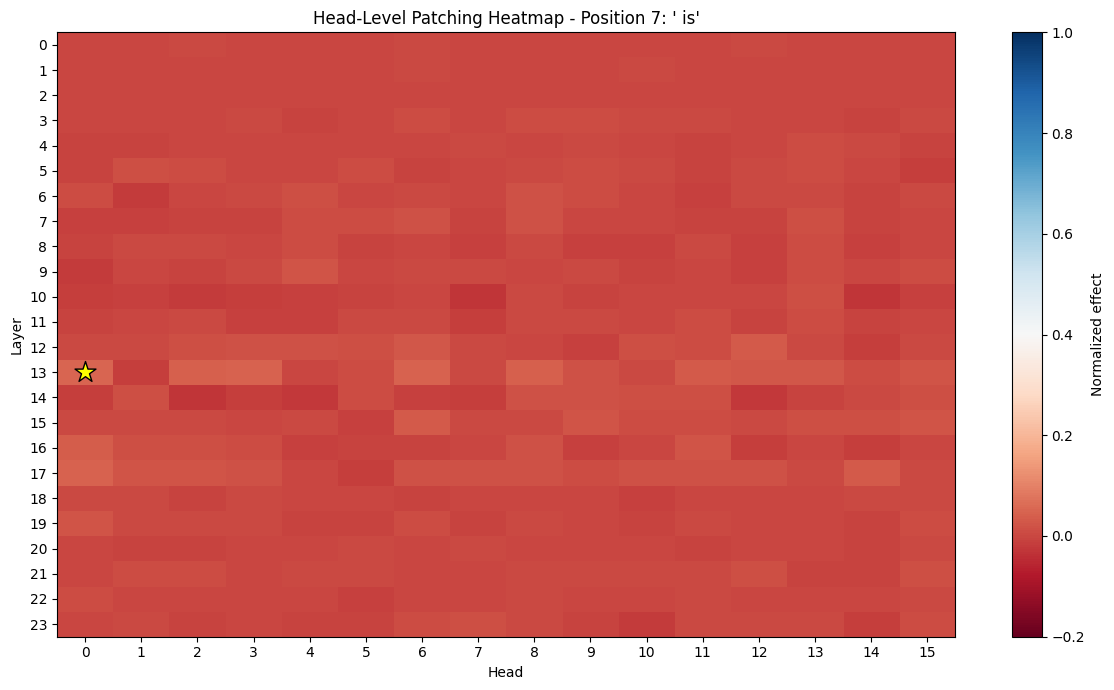

In [ ]:


# head_normalized shape = [n_layers, n_heads, seq_len]

for pos in range(seq_len):
    plt.figure(figsize=(12, 7))

    heat = head_normalized[:, :, pos]  # [layers, heads]

    im = plt.imshow(
        heat,
        aspect="auto",
        cmap="RdBu",
        vmin=-0.2,
        vmax=1.0
    )

    plt.colorbar(im, label="Normalized effect")
    plt.xlabel("Head")
    plt.ylabel("Layer")
    plt.title(f"Head-Level Patching Heatmap - Position {pos}: {tokens_clean[pos]!r}")

    plt.xticks(np.arange(n_heads))
    plt.yticks(np.arange(n_layers))

    best_layer, best_head = np.unravel_index(np.argmax(heat), heat.shape)

    plt.scatter(
        best_head,
        best_layer,
        marker="*",
        s=250,
        color="yellow",
        edgecolor="black"
    )

    plt.tight_layout()
    plt.show()

## 9. Reflexionsfragen

In [ ]:
# Beantworte folgende Fragen:
#
# 1. Was ist der Unterschied zwischen Activation Patching und Attention-Analyse?
#    Welche Methode gibt kausalere Aussagen?
#
# 2. In welcher Schicht und an welcher Position ist der Patching-Effekt am stärksten?
#    Was schließt du darüber, wo das "France → Paris"-Wissen verarbeitet wird?
#
# 3. Vergleiche mit Notebook 4 (Probing):
#    Stimmt die Schicht mit dem höchsten Probing-Score überein mit dem höchsten
#    Patching-Effekt? Was bedeutet eine Diskrepanz (falls es eine gibt)?
#
# 4. Welche Limitierungen hat Activation Patching?
#    (Denke an: Rechenkosten, Abhängigkeit vom Prompt-Paar, Superposition)
#
# 5. Wie könnte man Activation Patching auf Attention-Head-Ebene erweitern?
#    Was würde man dadurch lernen?